<a href="https://colab.research.google.com/github/usema07/bitcoin-classification-machine-learning/blob/main/PROGETTO_BITCOIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

L'obietto di questo progetto è quello di creare un modello di classificazione per prevedere un segnale di acquisto (Buy) o di vendita (Sell) di Bitcoin, a partire dal comportamento dei prezzi nel breve periodo rispetto al lungo periodo. Il modello scelto per raggiungere il nostro obiettivo è il Decision Tree.

In [ ]:
#Importiamo la libreria pandas
import pandas as pd

In [ ]:
#Qui carichiamo il nostro csv di riferimento, montato su Google Drive
from google.colab import drive
file_path = '/content/drive/MyDrive/MACHINE LEARNING/btcusd_1-min_data.csv'

Successivamente, abbiamo pulito il dataset andando a: eliminare minuti in cui non ci sono state transazioni; eliminare minuti in cui il prezzo è stato costante. Tutto ciò, con lo scopo di ridurre il rumore, ovvero limitare le informazioni che possono confondere il modello invece di aiutarlo a imparare.

In [ ]:
df = pd.read_csv(file_path)

df = df[df['Volume'] > 0]
df = df[df['Close'].diff() != 0]

/tmp/ipython-input-3-1623513323.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
# Visualizziamo alcune righe del nostro dataset
print(df.head())

         Timestamp  Open  High   Low  Close     Volume  \
627   1.325450e+09  4.84  4.84  4.84   4.84  10.000000   
1064  1.325476e+09  5.00  5.00  5.00   5.00  10.100000   
3284  1.325609e+09  5.32  5.32  5.32   5.32   2.419173   
3441  1.325619e+09  5.14  5.14  5.14   5.14   0.680000   
3473  1.325620e+09  5.26  5.26  5.26   5.26  29.319392   

                       datetime  
627   2012-01-01 20:28:00+00:00  
1064  2012-01-02 03:45:00+00:00  
3284  2012-01-03 16:45:00+00:00  
3441  2012-01-03 19:22:00+00:00  
3473  2012-01-03 19:54:00+00:00  


Per addestrare il nostro modello, abbiamo valutato nuove variabili predittive, per cui abbiamo scelto: le medie mobili per confrontare il prezzo di breve con quello di lungo periodo; il  momentum che misura come e quanto varia il trend, che sia rialzista o ribassista; la volatilità che indica il rischio; il return, invece, misura la variazione del Bitcoin minuto per minuto. Queste variabili ci permettono di determinare se è il momento di acquistare o di vendere.

In [ ]:
# Media mobile a breve termine
df['SMA_short'] = df['Close'].rolling(window=10).mean()

# Media mobile a lungo termine
df['SMA_long'] = df['Close'].rolling(window=50).mean()

correlation = df[['SMA_short', 'SMA_long']].corr()
print(correlation)

/tmp/ipython-input-5-2485875878.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SMA_short'] = df['Close'].rolling(window=10).mean()


           SMA_short  SMA_long
SMA_short   1.000000  0.999993
SMA_long    0.999993  1.000000


In [ ]:
df['Momentum'] = df['Close'] - df['Close'].shift(5)
df['Volatility'] = df['Close'].rolling(window=10).std()
df['SMA_ratio'] = df['SMA_short'] / df['SMA_long']
df['Return'] = df['Close'].pct_change()

Qui definiamo Future Close e Return Future. La prima variabile ci serve a capire quale sarà il prezzo del Bitocin tra n minuti, che nel nostro caso è 10. Per il Return Future, a seconda che sia maggiore di 0 o minore di 0, ci dice se ci sarà un guadagno atteso o una perdita attesa dopo 10 minuti. Così, abbiamo costruito quella che è la nostra variabile target, ovvero il Signal binario che ci suggerisce se acquistare o vendere.

In [ ]:
# Calcolo del prezzo futuro tra n minuti
n = 10
df['Future_Close'] = df['Close'].shift(-n)
df['Return_future'] = (df['Future_Close'] - df['Close']) / df['Close']
df['Signal'] = (
    (df['Return_future'] > 0.0015)
).astype(int)
print(df["Signal"].value_counts())
print(df['Signal'].value_counts(normalize=True))
df.dropna(inplace=True)

Signal
0    3887558
1    1232945
Name: count, dtype: int64
Signal
0    0.759214
1    0.240786
Name: proportion, dtype: float64


Per addestrare il modello abbiamo scelto come variabile dipendente la variabile Signal ed eliminato le covariate che ci davano problemi di rumore o di multicollinearità, come High e Low, strettamente legate ad Open e Close, e poi abbiamo utilizzato la SMA_ratio poiché le due medie mobili sono fortemente correlate tra di loro.

In [ ]:
X = df[[ "Open", "Close", "Volume", "Momentum", "Volatility", "SMA_ratio", "Return"]]
y = df['Signal']

Ora, suddividiamo il dataset 80% per l'addestramento e 20% per il test e, per evitare il problema dello sbilanciamento delle classi 0 ed 1, utilizziamo SMOTE, con lo scopo di riequilibrare le classi.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
#Importiamo SMOTE
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Inizializziamo SMOTE
sm = SMOTE(random_state=42)

# Applichiamo SMOTE solo sui dati di training
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

 Qui, costruiamo il nostro modello Decisione Tree, inserendo gli iperparametri, tra cui: la profondità pari a 3 livelli per una più chiara lettura dell'albero e utilizziamo il criterio tecnico dell'entropia, data la natura binaria del nostro obiettivo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Definiamo il modello
model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='sqrt',
    criterion='entropy',
    random_state=42
)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

model.fit(X_train_resampled, y_train_resampled)

Cross-validation accuracy: 0.7388022542460819


DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features='sqrt',
                       min_samples_leaf=5, min_samples_split=20,
                       random_state=42)

Nonostante un’accuracy abbastanza alta dell'81%, fatichiamo a riconoscere correttamente i segnali Buy, come evidenziano i valori molto bassi di precision, recall e di f1-score per la classe 1. Questo riflette un problema di sbilanciamento delle classi, come già accennato in precedenza. In particolare: l'accuracy ci dice quanto il modello classifica correttamente le osservazioni totali; la precision indica quante volte i segnali di acquisti o vendita sono giusti e quanti sono sbagliati; il recall quanti Buy o Sell veri trova; infine, l'f1-score indica l'equilibrio tra precision e recall.

In [ ]:
# Calcoliamo le probabilità di classe 1 (acquisto)
y_probs = model.predict_proba(X_test)[:, 1]

# Applicchiamo una soglia
y_pred = (y_probs > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[766579  67170]
 [123991  28985]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89    833749
           1       0.30      0.19      0.23    152976

    accuracy                           0.81    986725
   macro avg       0.58      0.55      0.56    986725
weighted avg       0.77      0.81      0.79    986725



L'accuracy che vediamo di seguito è riconducibile a quella esposta precedentemente, però qui tiene in considerazione quella globale (ovvero, entrambe le classi). Per quanto riguarda la training accuracy, rappresenta l'accuratezza sulle osservazioni usate per addestrare il modello. Il test accuracy invece, indica le prestazioni del modello sui dati mai visti prima. Generalmente, possiamo dire che il modello è abbastanza robusto considerando un buon valore di test accuracy ma un valore leggermente inferiore di training accuracy.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# Mettiamo in evidenza l'accuratezza
print("Accuracy:", accuracy_score(y_test, y_pred))

# Calcoliamo l'accuracy correttamente
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.8062671970407155
Training accuracy: 0.6762737917913744
Test accuracy: 0.8062671970407155


Dopo aver valutato le prestazioni del modello per ciascuna classe , calcoliamo le metriche globali pesate.
Queste metriche ci danno una visione complessiva del modello, tenendo conto dello sbilanciamento delle classi. I risultati ottenuti confermano che il modello ha una buona capacità predittiva complessiva.

In [ ]:
# Mostriamo il report di classificazione
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("\n=== Metriche Totali ===")
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1-score (weighted):", f1_score(y_test, y_pred, average='weighted'))


=== Metriche Totali ===
Precision (weighted): 0.7740577531825367
Recall (weighted): 0.8062671970407155
F1-score (weighted): 0.7873662299920287


L'albero inizia con una radice che utilizza il Return come primo criterio di split. Se il Return è minore di -0.001, il modello tende a classificare lo stato come Sell, il che ha senso: se il prezzo sta calando, è rischioso comprare.
A sinistra (Return > -0.001), il secondo split più rilevante è il prezzo di chiusura (Close), seguito dal Volume. Quando il prezzo è basso e il volume è contenuto, il modello tende a classificare la situazione come favorevole all'acquisto.
A destra (Return ≤ -0.001), l’albero sfrutta il Volume e il SMA_ratio come criteri di riferimento per prendere una decisione. Quando il rapporto tra le medie mobili è molto vicino a 1, prevale la classe Sell.
Abbiamo scelto di utilizzare una profondità pari a 3 per semplicità di interpretazione.
Il valore di entropia diminuisce man mano che ci si sposta verso le foglie, indicando una prevalenza di una classe rispetto all'altra.
In sintesi, possiamo affermare che l’albero ha imparato a distinguere pattern nei dati.

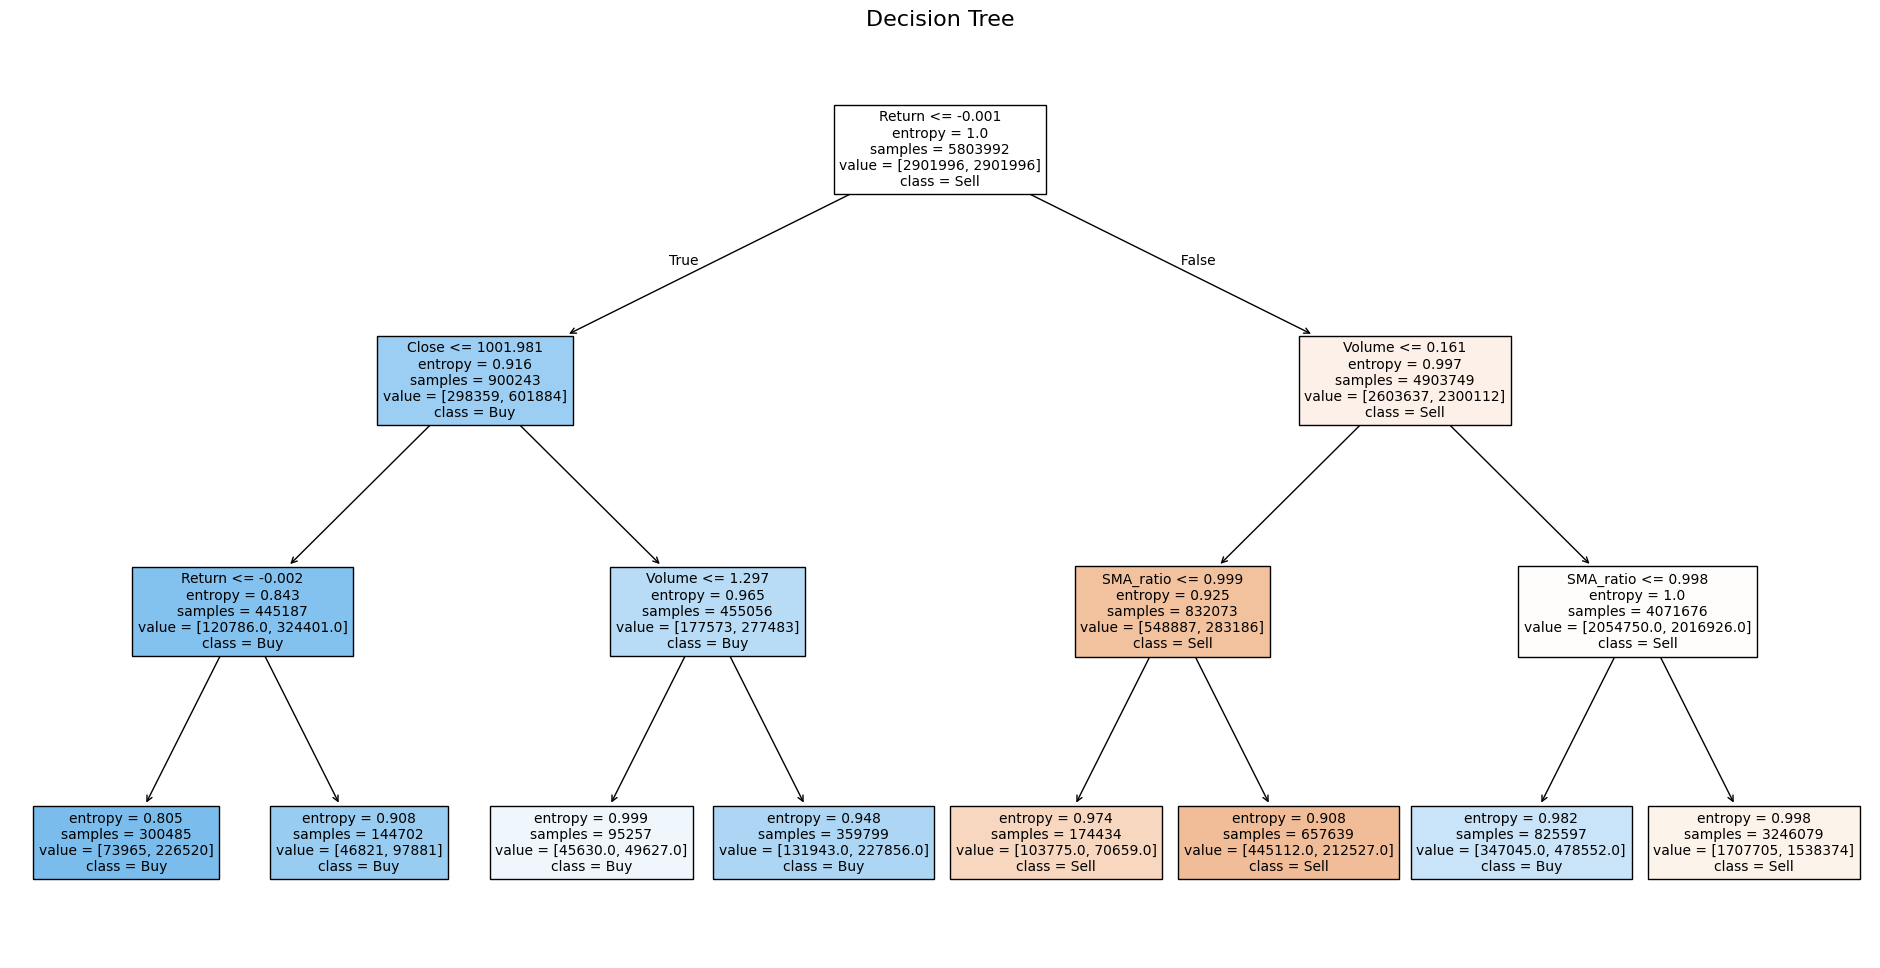

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

#Grafico dell’albero
plt.figure(figsize=(24, 12))  # Dimensioni del grafico
plot_tree(
    model,
    filled=True,            # Coloriamo i nodi in base alla classe
    feature_names=X.columns,  # Nomi delle variabili
    class_names=["Sell", "Buy"],  # Nomi delle classi (0, 1)
    proportion=False,       # Valori assoluti
    fontsize=10
)
plt.title("Decision Tree", fontsize=16)
plt.show()